# Fake News Detection with TF-IDF and Logistic Regression

This project builds a text classification model to distinguish between real and fake news articles using natural language processing and machine learning.

The workflow includes:
- loading and preparing the dataset
- combining article title and body text
- training a TF-IDF + Logistic Regression baseline model
- evaluating performance with classification metrics and a confusion matrix
- interpreting important keywords
- testing the model on a real-world news article outside the original dataset

The goal is not only to build an accurate classifier, but also to understand how the model makes decisions and how well it generalizes beyond the training data.

## 1. Load the Dataset

The dataset used in this project comes from the Kaggle **Fake and Real News Dataset**. It is a binary text classification dataset commonly used for fake news detection tasks. The dataset is provided in two separate CSV files: `Fake.csv` and `True.csv`. According to the dataset description, `Fake.csv` contains 23,502 fake news articles and `True.csv` contains 21,417 real news articles. The Kaggle page also describes it as the **ISOT Fake News detection dataset**.

Each file includes article-level text fields such as:
- `title`
- `text`
- `subject`
- `date`

In this step, both files are loaded into pandas dataframes so the raw structure of the dataset can be inspected before preprocessing and modeling.

In [2]:
import pandas as pd

fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

print("Fake shape:", fake_df.shape)
print("True shape:", true_df.shape)
fake_df.head()

Fake shape: (23481, 4)
True shape: (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


## 2. Label and Combine the Data

To turn the dataset into a binary classification problem, a label is assigned to each article:
- `1` for fake news
- `0` for real news

After labeling, the two dataframes are concatenated into a single combined dataset that will be used for the rest of the analysis.

In [4]:
fake_df["label"] = 1
true_df["label"] = 0

df = pd.concat([fake_df, true_df], axis=0)

print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


## 3. Shuffle the Dataset

After combining the fake and real articles, the dataset is shuffled so that the rows are randomly mixed. This is important because the combined dataframe originally places all fake articles first and all real articles second. Shuffling helps ensure that later training and evaluation are not affected by the original ordering of the data.

In [6]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


## 4. Create the Text Input Feature

To prepare the text for modeling, the `title` and `text` columns are combined into a single field called `content`. This gives the classifier access to both the headline and the article body when learning to distinguish between real and fake news.

Missing values are replaced with empty strings before combining the columns so that the text processing step runs without errors.

In [9]:
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

df["content"] = df["title"] + " " + df["text"]

df[["title", "text", "content", "label"]].head()

,title,text,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",Ben Stein Calls Out 9th Circuit Court: Committ...,1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,Trump drops Steve Bannon from National Securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,Puerto Rico expects U.S. to lift Jones Act shi...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",OOPS: Trump Just Accidentally Confirmed He Le...,1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",Donald Trump heads for Scotland to reopen a go...,0


## 5. Train-Test Split

The dataset is split into training and test sets so that model performance can be evaluated on unseen data.

In this project:
- **80%** of the data is used for training
- **20%** of the data is used for testing

Stratified sampling is applied to preserve the proportion of real and fake articles in both sets.

In [29]:
from sklearn.model_selection import train_test_split

X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35918,)
X_test shape: (8980,)
y_train shape: (35918,)
y_test shape: (8980,)


### Check Label Distribution

After splitting the data, it is helpful to confirm that the proportion of real and fake articles remains similar in both the training and test sets.

In [12]:
print("Train label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train label distribution:
label
1    18785
0    17133
Name: count, dtype: int64

Test label distribution:
label
1    4696
0    4284
Name: count, dtype: int64


## 6. Build the Baseline Model

A baseline text classification model is created using **TF-IDF** and **Logistic Regression**.

- **TF-IDF vectorization** converts the text into numerical features based on word importance
- **Logistic Regression** is then used to classify each article as real or fake

This is a strong and widely used baseline for NLP classification tasks because it is efficient, interpretable, and often performs very well on text data.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=20000,
        ngram_range=(1, 2)
    )),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

## 7. Evaluate the Model

After generating predictions on the test set, the model is evaluated using standard classification metrics.

The main metrics reported here are:
- **Accuracy**: the overall proportion of correct predictions
- **Precision**: how often predicted positive cases are correct
- **Recall**: how many actual positive cases are successfully identified
- **F1-score**: the balance between precision and recall

In [30]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9902004454342984

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### Baseline Results Summary

The TF-IDF + Logistic Regression baseline performs extremely well on the test set.

Key results:
- **Accuracy:** 0.9902
- **Precision:** 0.99 for both classes
- **Recall:** 0.99 for both classes
- **F1-score:** 0.99 for both classes

These results indicate that the model is highly effective at distinguishing between real and fake news within this dataset.

## 8. Confusion Matrix

A confusion matrix provides a more detailed view of model performance by showing how many articles were classified correctly and where errors occurred.

In this project:
- `0` = Real
- `1` = Fake

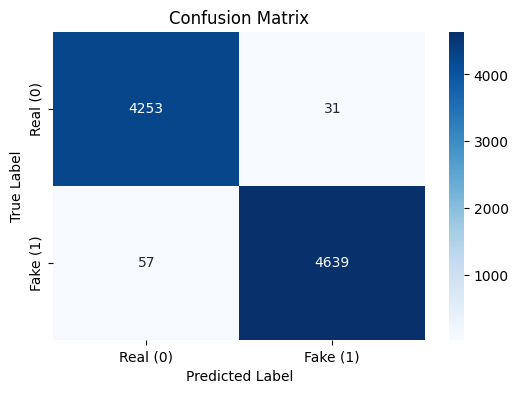

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real (0)", "Fake (1)"],
    yticklabels=["Real (0)", "Fake (1)"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## 9. Interpret Important Features

Because the baseline classifier uses Logistic Regression, it is possible to inspect the learned coefficients and identify which words or phrases are most strongly associated with each class.

In this model:
- **larger positive coefficients** are more associated with **Fake news**
- **larger negative coefficients** are more associated with **Real news**

This helps make the model more interpretable by showing which features contribute most strongly to its predictions.

In [23]:
import pandas as pd

feature_names = model.named_steps["tfidf"].get_feature_names_out()
coefficients = model.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df_sorted = coef_df.sort_values("coefficient", ascending=False)

print("Top 20 words/phrases most associated with Fake news:")
print(coef_df_sorted.head(20))

print("\nTop 20 words/phrases most associated with Real news:")
print(coef_df_sorted.tail(20))

Top 20 words/phrases most associated with Fake news:
               feature  coefficient
19098            video     9.335343
9352              just     6.755709
7987           hillary     5.726359
14067             read     5.524757
7394               gop     5.518889
13406  president trump     5.376790
8360             image     4.949638
6526    featured image     4.898005
6525          featured     4.877211
11910            obama     4.814158
19399            watch     4.711480
1135           america     4.573551
11307               mr     4.449039
3510               com     4.014271
10049             like     3.715328
7267             getty     3.640061
2396          breaking     3.568026
7268      getty images     3.495911
1145          american     3.478513
13389  president obama     3.343457

Top 20 words/phrases most associated with Real news:
                  feature  coefficient
3560              comment    -2.893099
17980        told reuters    -2.893824
4754           democ

### Visualizing the Most Important Features

To make the coefficient results easier to interpret, the most influential features for both classes are visualized below. The first chart shows the features most strongly associated with fake news, while the second chart shows the features most strongly associated with real news.

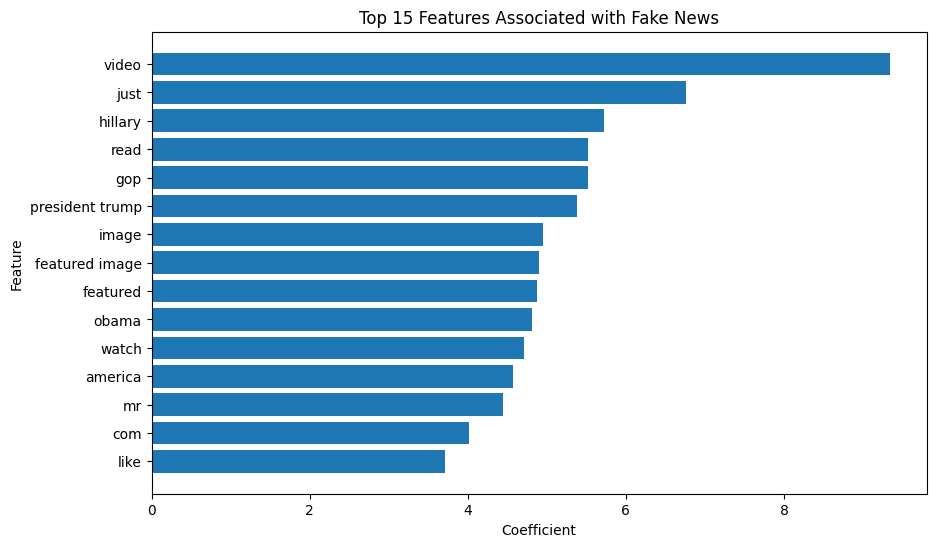

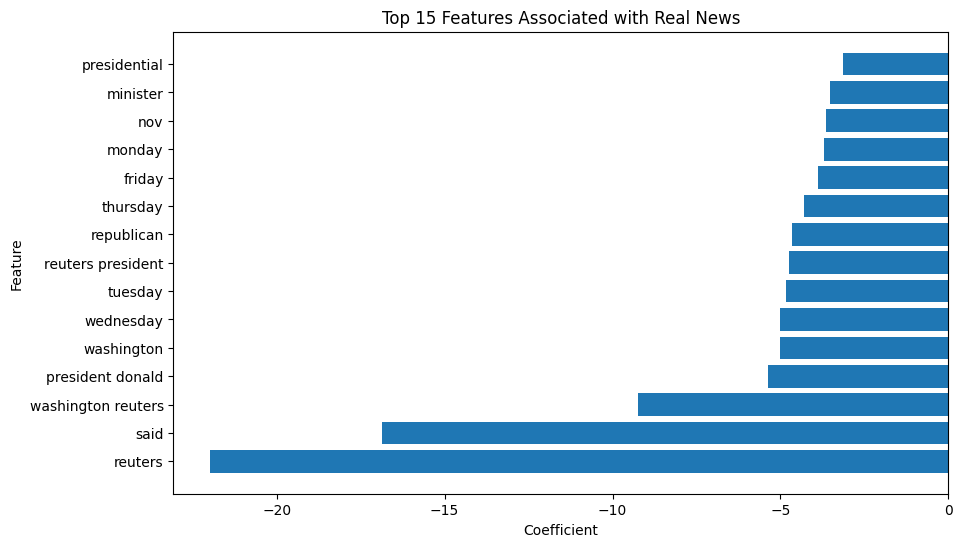

In [24]:
import matplotlib.pyplot as plt

top_fake = coef_df_sorted.head(15).sort_values("coefficient")
top_real = coef_df_sorted.tail(15).sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_fake["feature"], top_fake["coefficient"])
plt.title("Top 15 Features Associated with Fake News")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(top_real["feature"], top_real["coefficient"])
plt.title("Top 15 Features Associated with Real News")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

## 10. Real-World Test Case

To evaluate whether the model can generalize beyond the original dataset, an external real-world news article is tested separately. This article comes from *The Wall Street Journal* and was not part of the Kaggle training data.

Testing an out-of-sample article is useful because strong performance on the original test set does not necessarily guarantee strong performance on new, real-world text from different publishers.

In [28]:
real_article = """
OpenAI CEO Apologizes for Not Flagging Mass Shooting Suspect to Police
Sam Altman said AI company will work more closely with governments to prevent future tragedies
OpenAI Chief Executive Sam Altman apologized to the Canadian town of Tumbler Ridge for not alerting police sooner to the activity of Jesse Van Rootselaar, the suspect in a February mass shooting that killed eight people.

In a letter dated April 23, Altman said he was sorry OpenAI didn’t contact law enforcement about Van Rootselaar, whose ChatGPT account the company suspended last June.

“I want to express my deepest condolences to the entire community,” Altman wrote. “No one should ever have to endure a tragedy like this.”

OpenAI’s automated review system internally flagged messages from Van Rootselaar describing violent scenarios, resulting in her account being banned. Some employees interpreted her writings as an indication of potential real-world violence, and urged leaders to alert Canadian law enforcement. OpenAI leaders decided not to contact authorities, The Wall Street Journal has reported.

In February, police identified Van Rootselaar, an 18-year-old transgender woman, as the suspect in the Tumbler Ridge mass shooting.

OpenAI has said that once Van Rootselaar’s name was shared publicly after the shooting, the company discovered a second ChatGPT account Van Rootselaar was using.

British Columbia Premier David Eby lays flowers at a makeshift memorial for mass shooting victims in Tumbler Ridge.
Officials lay flowers at a makeshift memorial for the victims of a deadly mass shooting in Tumbler Ridge, British Columbia, in February. Jennifer Gauthier/Reuters
In his letter, Altman said he reaffirmed a commitment he made to the Tumbler Ridge Mayor and British Columbia Premier to find ways to prevent tragedies like what happened in Tumbler Ridge in the future.

“Going forward, our focus will continue to be on working with all levels of government to help ensure something like this never happens again,” Altman wrote.

The apology was first published by the local community newspaper Tumbler RidgeLines.

OpenAI has said that it has bolstered safety protocols since the shooting, and said under its enhanced law enforcement referral rules, it would have referred Van Rootselaar’s account to law enforcement if it were discovered today.

In March, Canadian lawmakers said Altman had agreed to issue an apology to Tumbler Ridge’s residents.

British Columbia Premier David Eby said Wednesday the ministry of public safety has been informed by police that they are in the final stages of their investigation into the shooting.

Tumbler Ridge Mayor Darryl Krakowka didn’t immediately respond to a request for comment. Earlier this week, he told reporters in Victoria, British Columbia, that town residents continue to grieve. Some have started the healing process, “but some others haven’t. It feels like yesterday to me, but it’s been a few months.”

Representatives for Canada’s minister in charge of artificial intelligence, Evan Solomon, didn’t respond to a request for comment. This month, nationwide members of the governing Liberal Party approved a nonbinding resolution calling for a ban on the use of AI chatbots for youth under the age of 16.

Solomon and other senior Canadian officials have said they are considering AI regulations but no final decisions have been made.

News Corp, owner of The Wall Street Journal, has a content-licensing partnership with OpenAI.
"""

pred = model.predict([real_article])[0]
prob = model.predict_proba([real_article])[0]

label_map = {0: "Real", 1: "Fake"}

print("Predicted label:", label_map[pred])
print("Probability [Real, Fake]:", prob)

Predicted label: Real
Probability [Real, Fake]: [0.82547934 0.17452066]


### Real-World Test Result

The model classified this external Wall Street Journal article as **Real** with a probability of **0.8255**. This suggests that the model can generalize beyond the original dataset, although it may still rely partly on source style and reporting conventions.